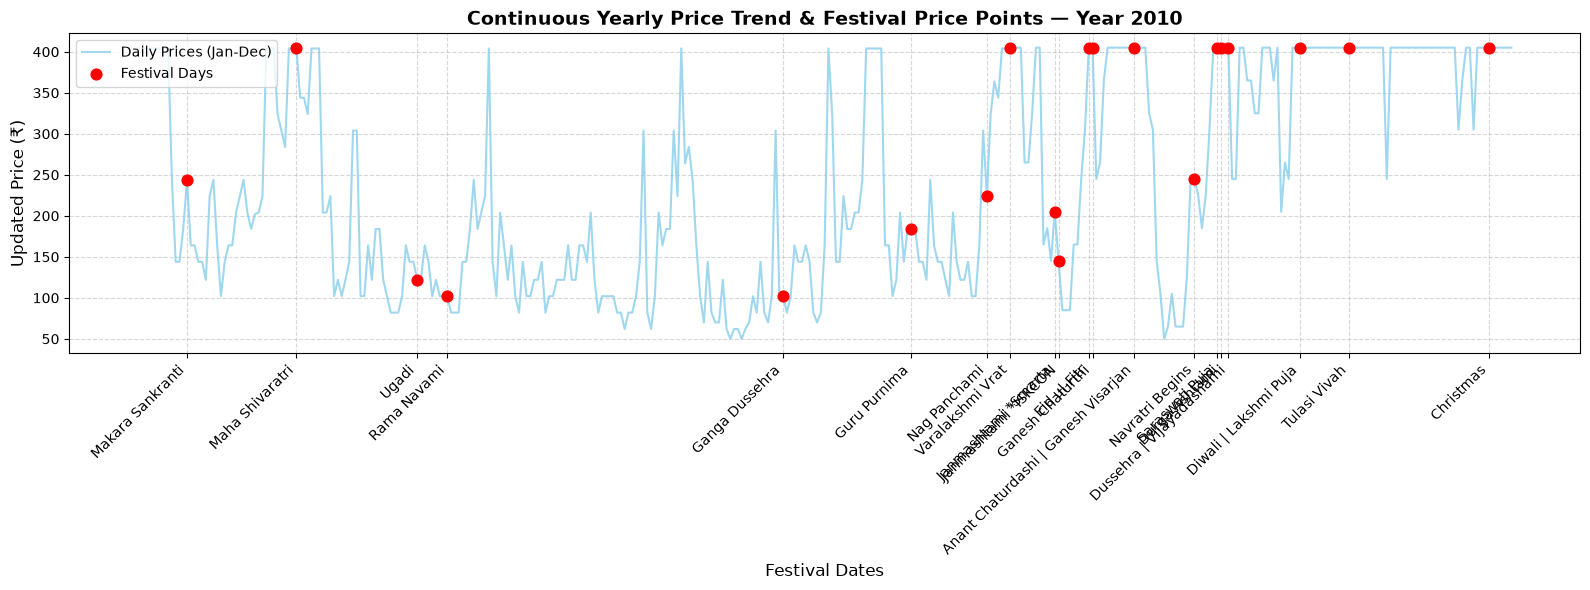

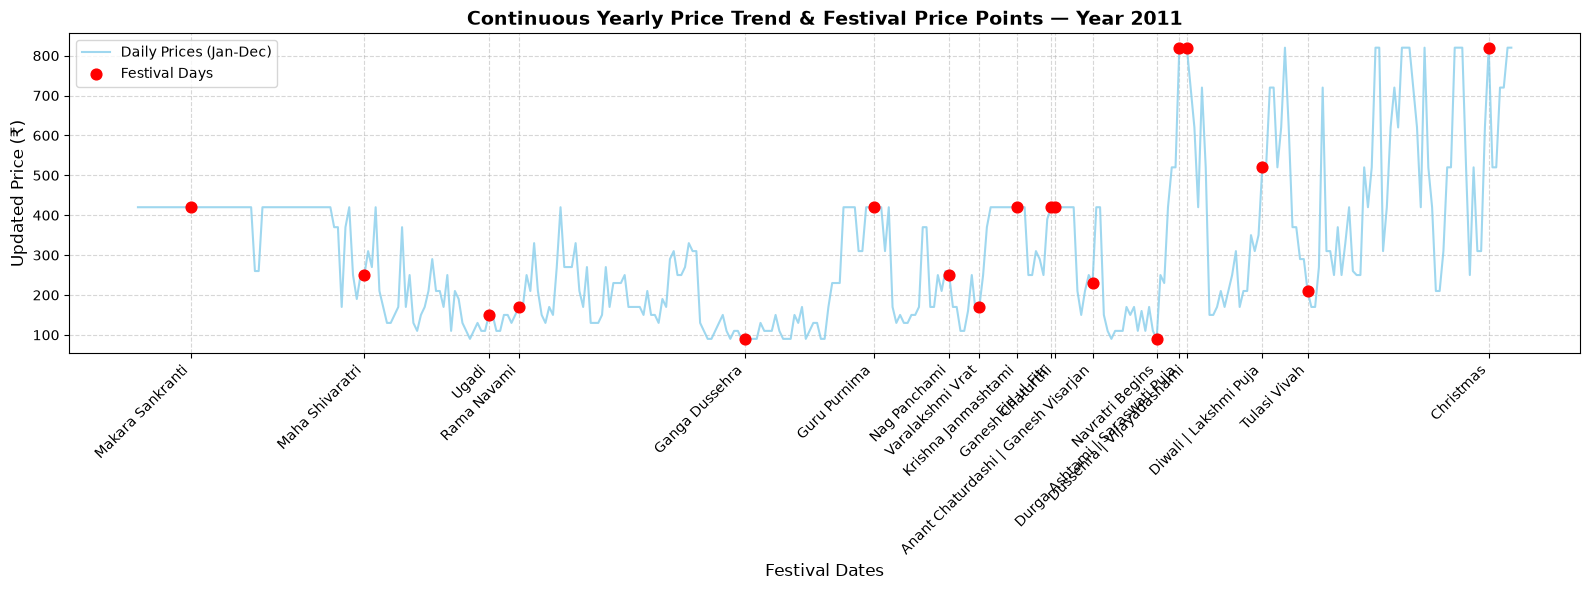

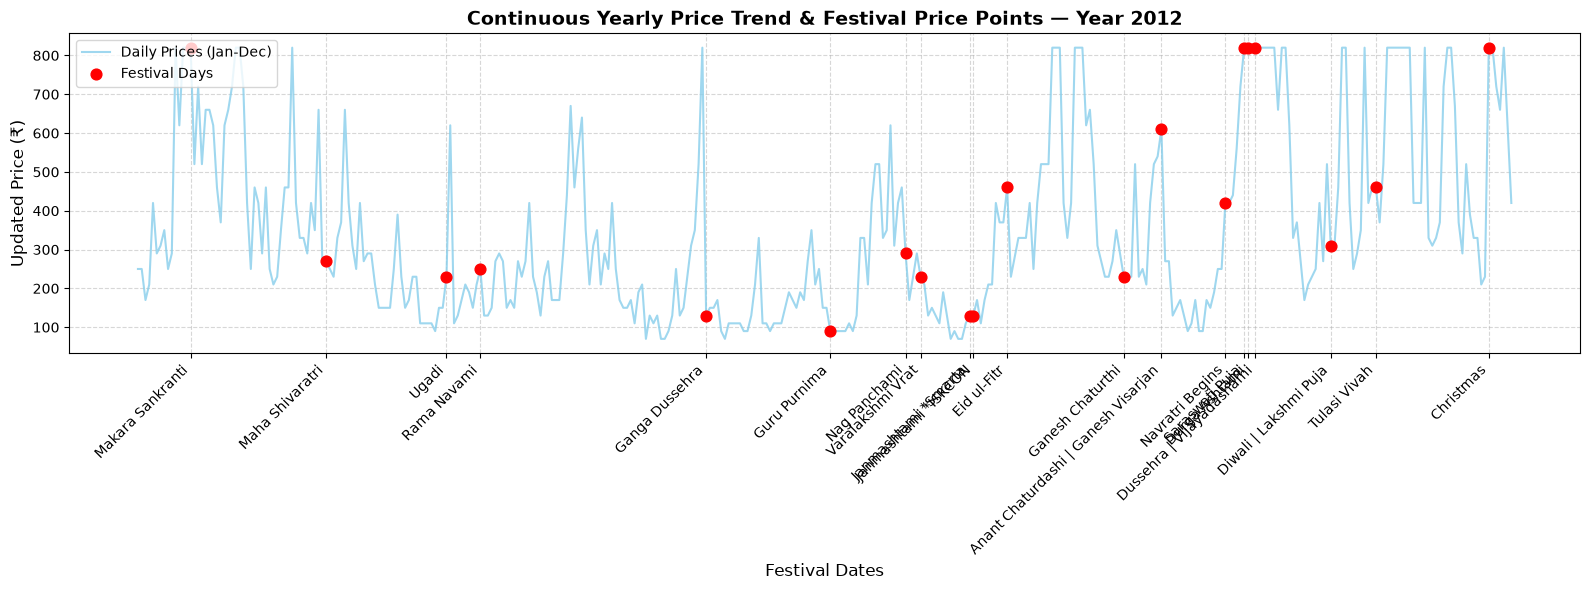

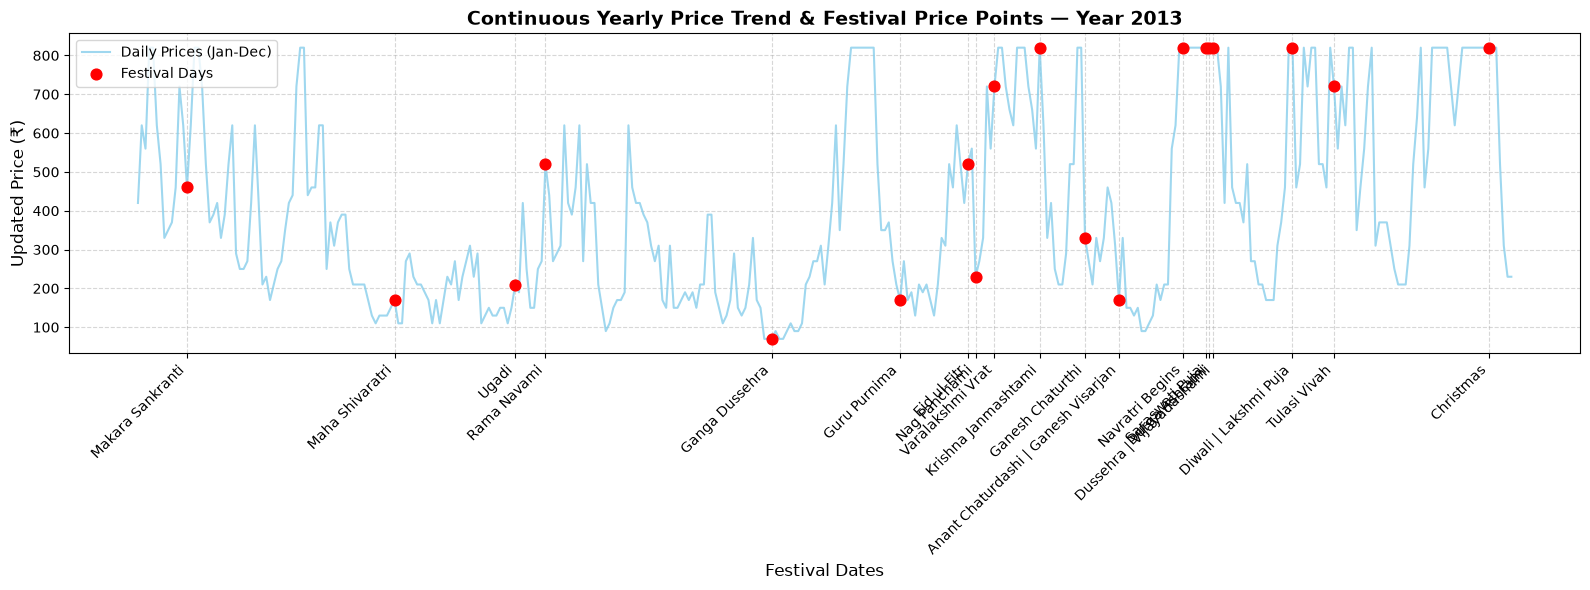

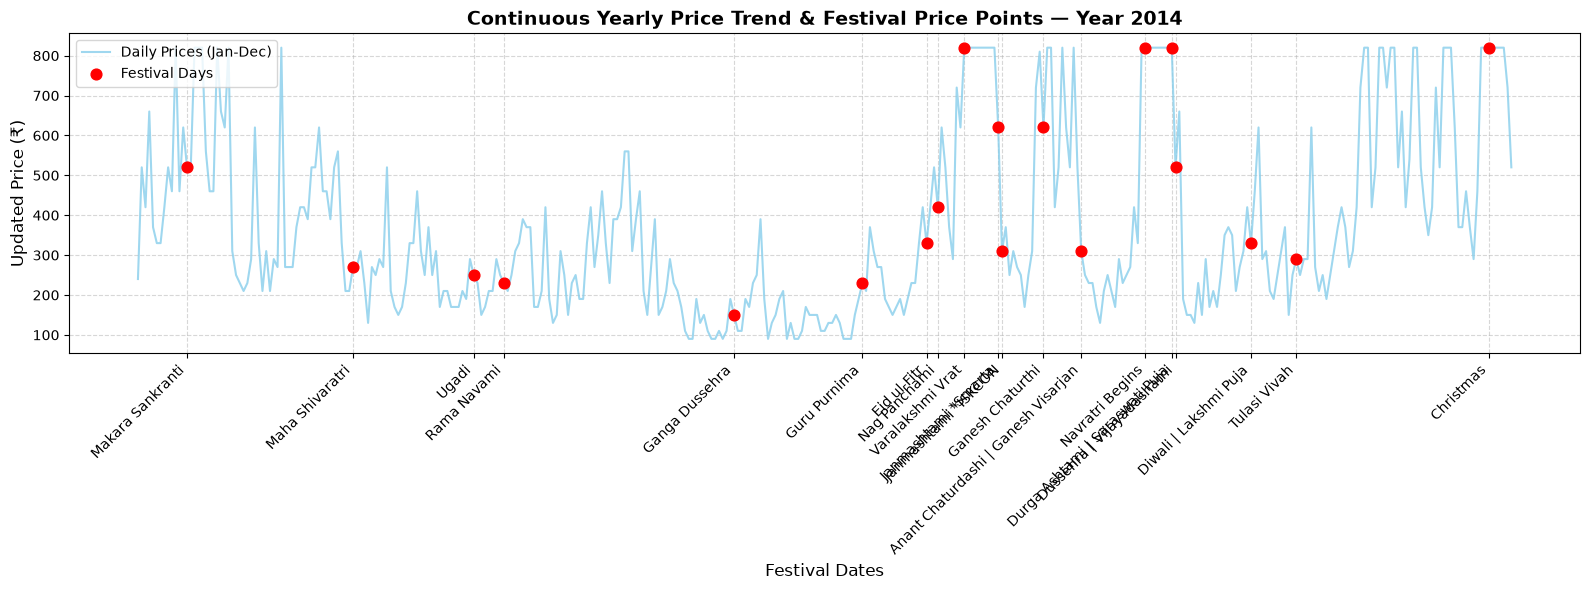

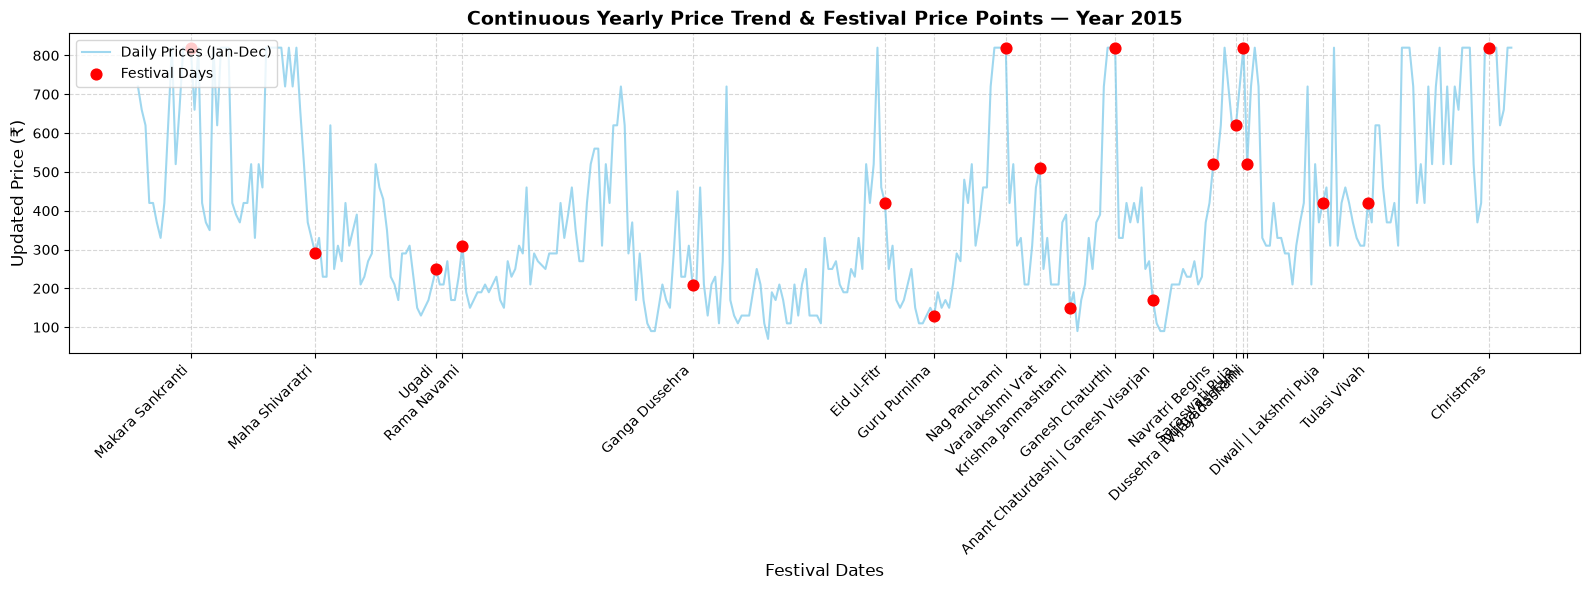

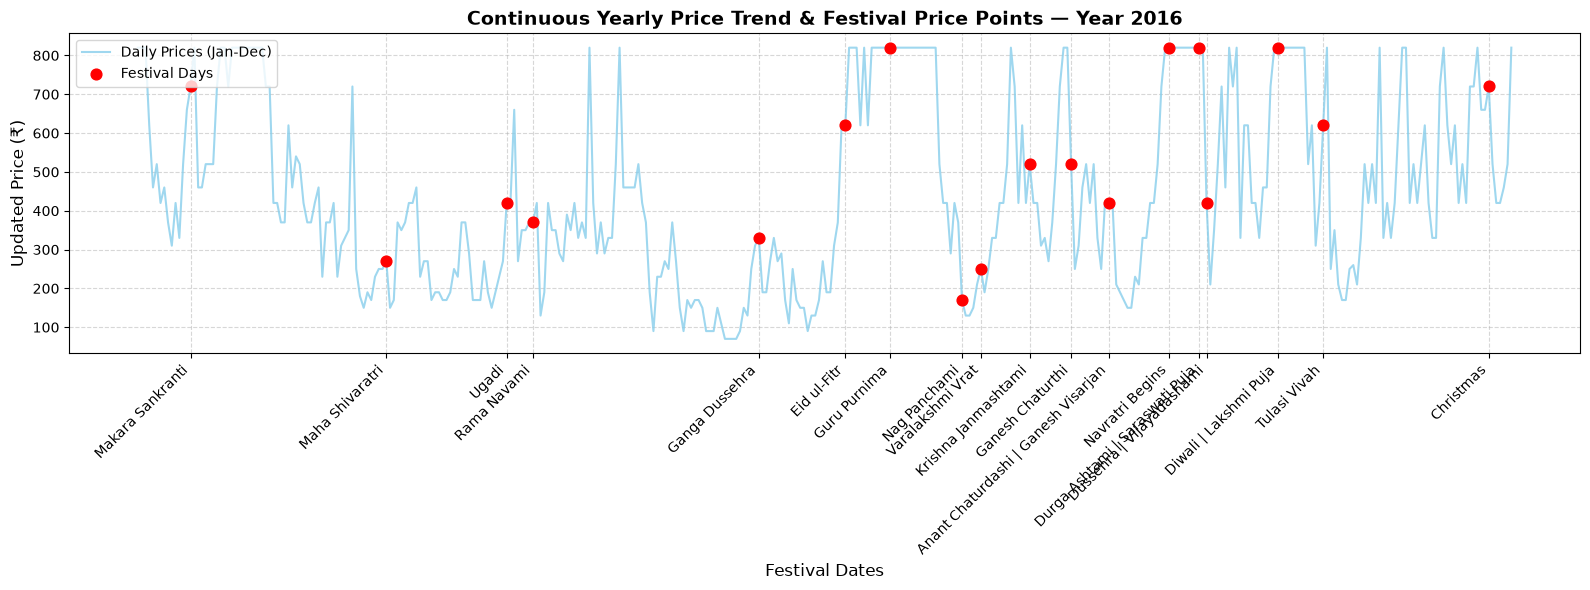

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================================
# 1. LOAD AND PREPARE DATASET
# =========================================================================
CSV_PATH = r'C:\Project\data\processed\flower_prices_cleaned.csv'
df = pd.read_csv(CSV_PATH)

# Convert DATE to datetime and extract Year
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df['DATE'].dt.year

years = sorted(df['Year'].unique())

# =========================================================================
# 2. GENERATE SEPARATE YEARLY LINE GRAPHS (Jan-Dec with Festival X-Ticks)
# =========================================================================
for yr in years:
    # Create a full date range from Jan 1 to Dec 31 for continuity
    full_range = pd.date_range(start=f'{yr}-01-01', end=f'{yr}-12-31')
    
    # Filter original data for the specific year and reindex to cover all days
    df_yr = df[df['Year'] == yr].set_index('DATE').reindex(full_range).reset_index()
    df_yr.rename(columns={'index': 'DATE'}, inplace=True)
    df_yr['Year'] = yr
    
    # Extract only the festival days for this year, sorted chronologically
    fest_subset = df[(df['Year'] == yr) & (df['is_festival'] == 1) & (df['festival_name'].notna())].sort_values('DATE')
    
    plt.figure(figsize=(16, 6))
    
    # Plot the full daily price trend line across the entire year
    plt.plot(df_yr['DATE'], df_yr['price_updated'], color='skyblue', linewidth=1.5, label='Daily Prices (Jan-Dec)', alpha=0.8)
    
    # Highlight specific festival points on the line with red markers
    plt.scatter(fest_subset['DATE'], fest_subset['price_updated'], color='red', s=60, zorder=5, label='Festival Days')
    
    # Set X-axis ticks and labels strictly to the festival dates and names
    plt.xticks(fest_subset['DATE'], fest_subset['festival_name'], rotation=45, ha='right', fontsize=10)
    
    plt.title(f'Continuous Yearly Price Trend & Festival Price Points — Year {yr}', fontsize=14, fontweight='bold')
    plt.xlabel('Festival Dates', fontsize=12)
    plt.ylabel('Updated Price (₹)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()